# **Task Description**

You are required to build a console-based chatbot that communicates with users in natural language using a pre-trained transformer model. The chatbot should dynamically generate responses and simulate a basic conversational AI assistant.



In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

def start_chatbot():
    # 1. Model Loading
    model_name = "Qwen/Qwen2.5-1.5B-Instruct"
    print(f"Loading {model_name}... This will take a moment.")

    # Load tokenizer and model.
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

    # We will use a list to keep track of the conversation history
    messages = [
        {"role": "system", "content": "You are a helpful, smart AI assistant."}
    ]

    print(f"\nChatbot initialized on {device.upper()}!")
    print("--------------------------------------------------")

    while True:
        # 2. User Input Handling
        user_input = input("You: ")

        # 5. Exit Condition
        if user_input.strip().lower() in ["exit", "quit"]:
            print("Chatbot: Goodbye!")
            break

        # Add the user's message to the history
        messages.append({"role": "user", "content": user_input})

        # Apply the chat template to format the history for the model
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        model_inputs = tokenizer([text], return_tensors="pt").to(device)

        # 3. Response Generation
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=256, # how long the answer can be
            temperature=0.7,    # A good balance of creative and factual
            do_sample=True
        )

        # Extract only the newly generated tokens
        generated_ids = [
            output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]

        # Decode the response
        response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

        print(f"Chatbot: {response}")

        # 4. Continuous Conversation: Save the bot's response to the history
        messages.append({"role": "assistant", "content": response})

if __name__ == "__main__":
    start_chatbot()

After uploading this file with output, in github the github shows "Invalid Notebook" error, happens because my notebook file contains metadata from the progress bars (tqdm) or widgets used during the Hugging Face model download.

so i have attached the screenshot of the output


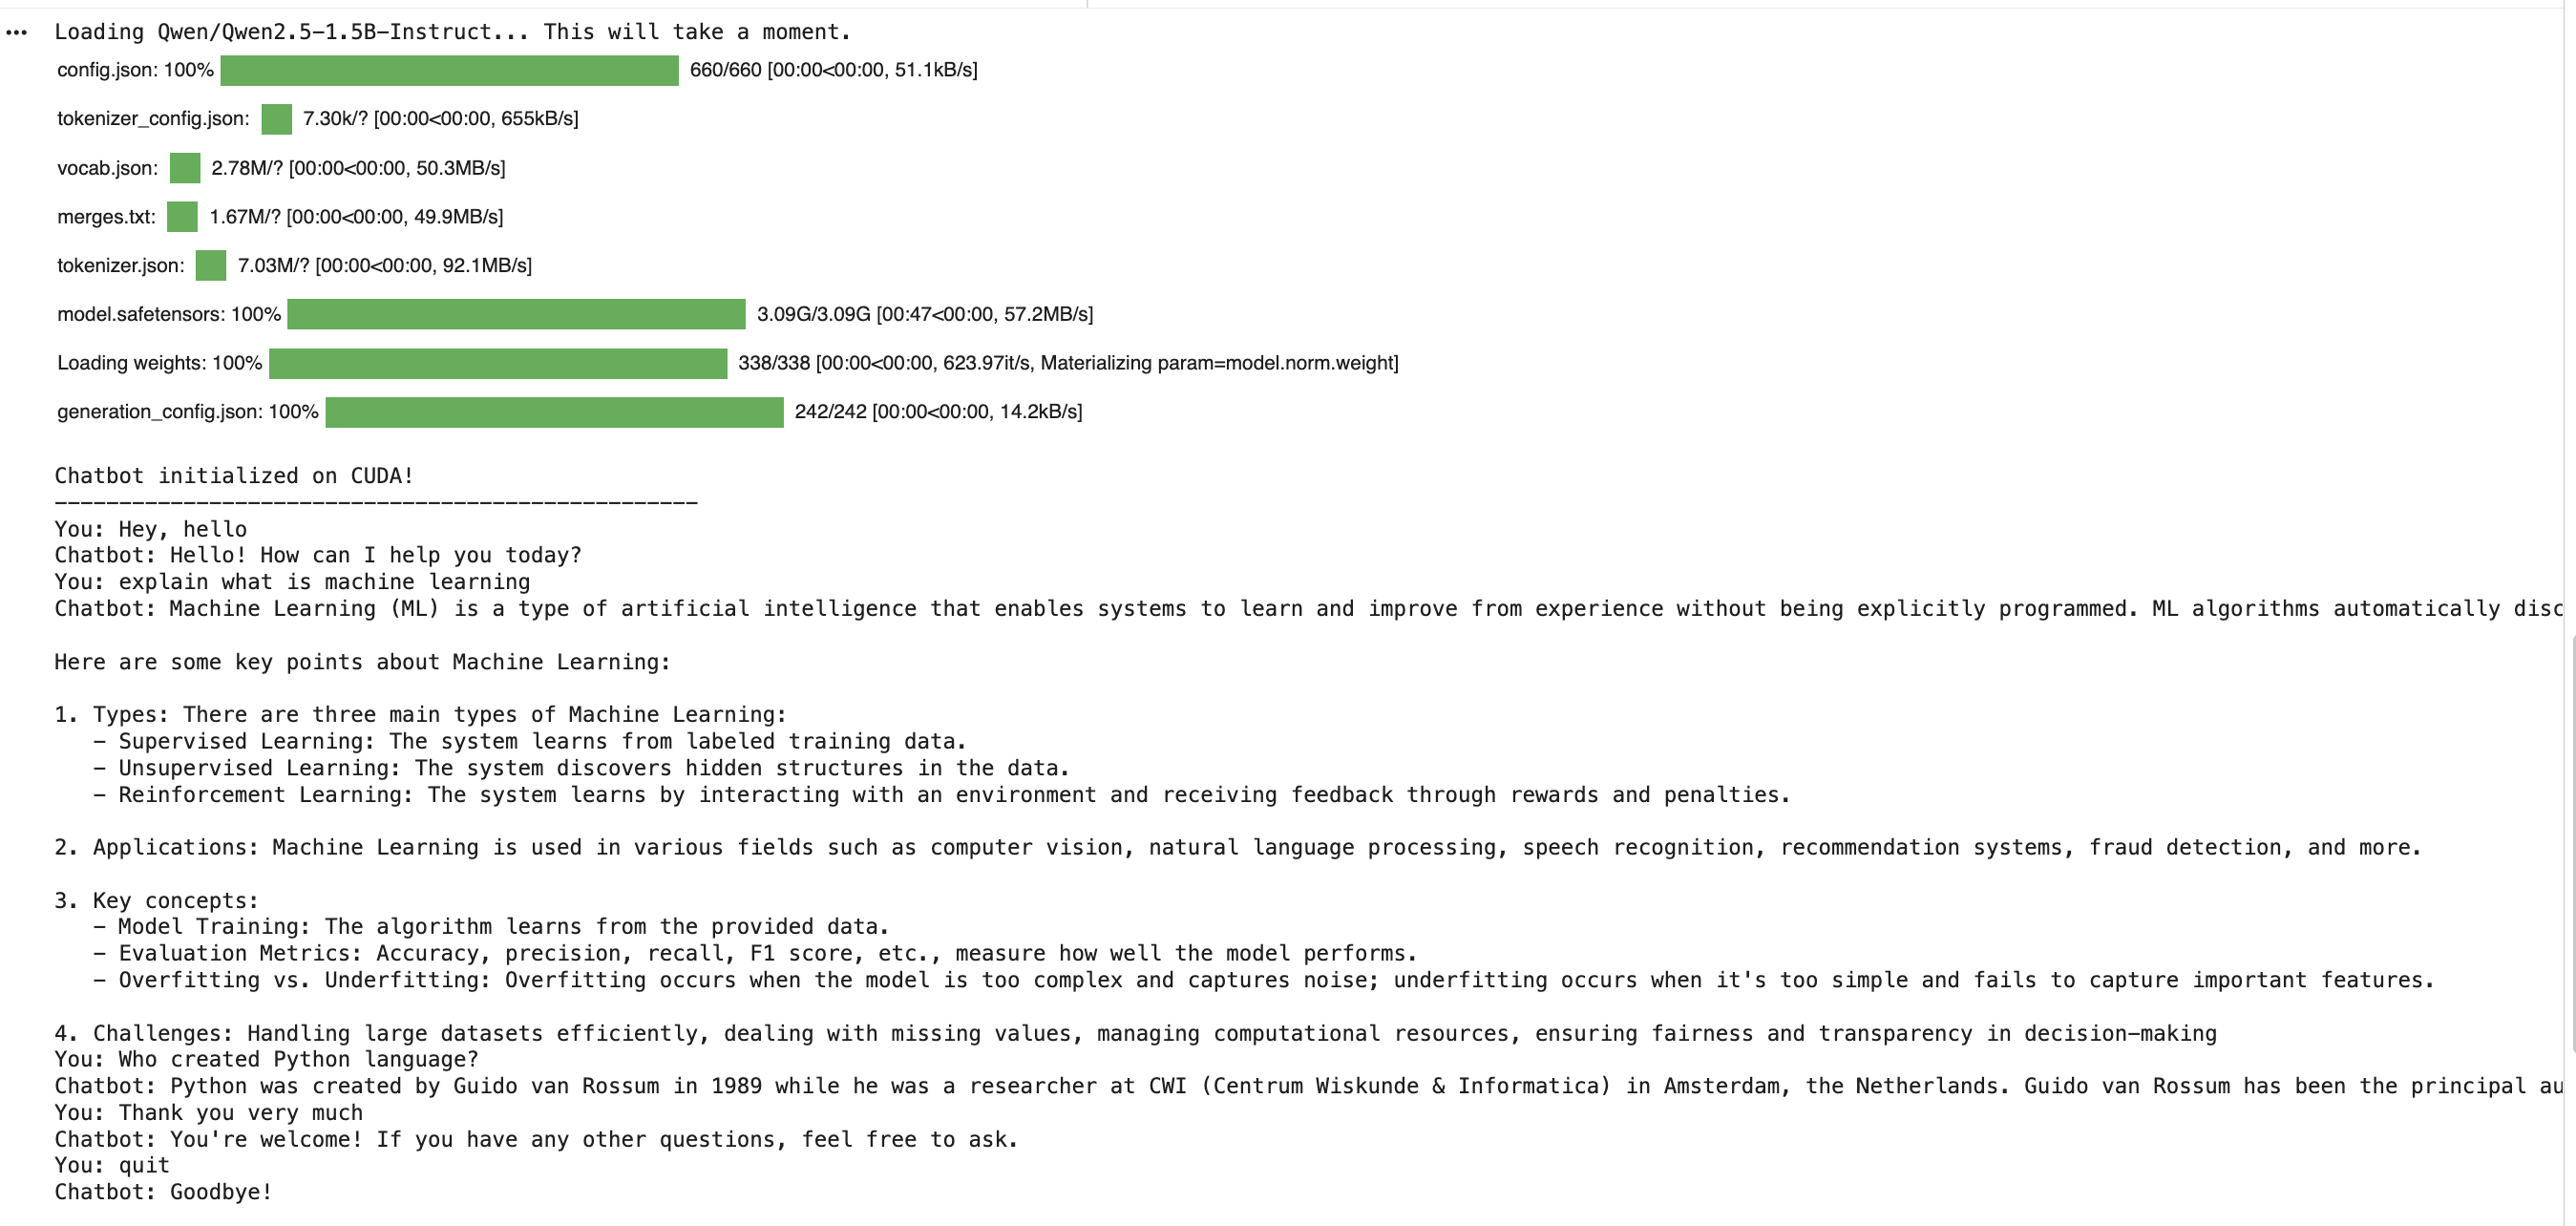